In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv(
    "../data/raw/mercari_train.tsv",
    sep="\t"
)

train.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


# 03. 탐색적 데이터 분석 (EDA)

## 3.1 Target 변수 분석

본 프로젝트의 목표변수인 `price`의 분포와 중심 경향, 변동성을 확인하여 상품 가격 데이터의 특성을 파악한다.

특히 평균과 중앙값의 차이, 가격의 분포 형태 및 극단값의 존재 여부를 확인하고, 이후 통계적 회귀분석과 머신러닝 모델링에서 적절한 Target 변환이 필요한지 검토한다.

In [2]:
train["price"].describe()

count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64

### 3.1.1 가격 기초통계량

`price`의 기초통계량을 확인한 결과, 전체 1,482,535개 상품의 평균 가격은 26.74이며 중앙값은 17.00으로 나타났다.

평균이 중앙값보다 높고 최대값이 2,009로 중앙값에 비해 크게 나타나 일부 고가 상품이 전체 가격의 평균을 높이고 있을 가능성이 확인되었다. 따라서 가격 분포가 오른쪽으로 치우친 형태를 보일 가능성이 있다.

한편 전체 상품의 중앙 50%는 가격 10~29 구간에 위치하여 비교적 낮은 가격대에 집중되어 있는 것으로 나타났다.

다만 기초통계량만으로 가격 분포의 형태를 확정할 수 없으므로, 이후 시각화를 통해 가격의 왜도와 극단값의 분포를 추가적으로 확인한다.

또한 최소 가격이 0으로 나타났으며, 앞선 데이터 품질 검증에서 확인한 874개의 `price = 0` 관측치가 이에 해당한다. 해당 관측치는 이후 전처리 단계에서 처리한다.

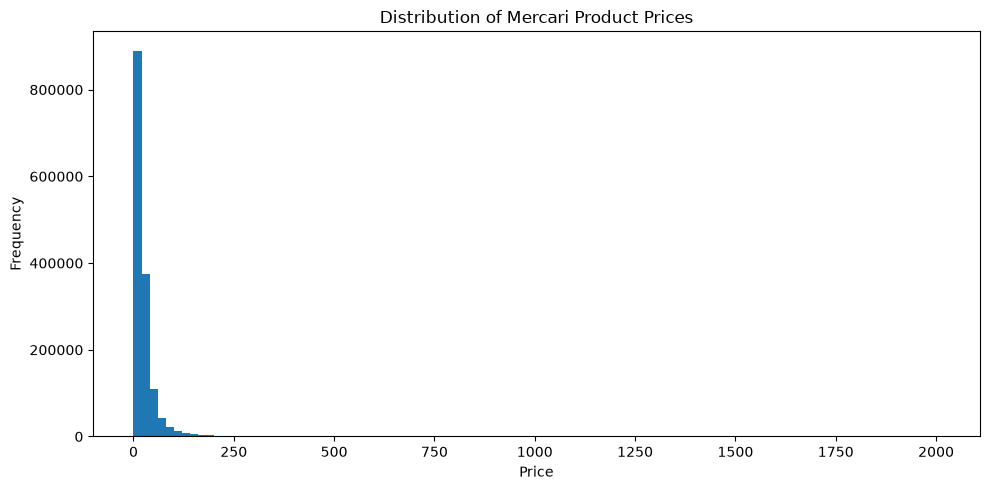

In [3]:
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.hist(train["price"], bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Mercari Product Prices")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 3.1.2 가격 분포 시각화

가격의 분포를 시각화한 결과, 대부분의 상품이 낮은 가격대에 집중되어 있으며 고가 상품이 오른쪽으로 길게 분포하는 우측 왜도(right skewness)가 나타났다.

이는 앞서 확인한 평균 가격(26.74)이 중앙값(17.00)보다 높은 결과와 일치한다. 일부 고가 상품이 존재하면서 가격의 평균을 상승시키고 있는 것으로 해석할 수 있다.

이러한 비대칭적인 가격 분포는 선형 회귀모형의 적합과 잔차 구조에도 영향을 줄 수 있으므로, 이후 통계적 분석에서는 원래 가격을 사용하는 모형과 로그 변환된 가격을 사용하는 모형을 비교할 필요가 있다.

따라서 이후 분석에서는 가격 분포의 왜도를 정량적으로 확인하고, 로그 변환을 적용했을 때 분포가 어떻게 변화하는지 추가적으로 검토한다.

In [4]:
train["price"].skew()

np.float64(11.393232000122524)

### 3.1.3 가격 분포의 왜도 검정

가격 변수의 왜도(skewness)를 계산한 결과 **11.39**로 나타났다.

왜도는 0에 가까울수록 대칭적인 분포를 의미하며, 양수일수록 오른쪽 꼬리가 긴 분포를 나타낸다. 본 데이터의 왜도는 상당히 큰 양의 값을 나타내고 있어 가격 분포가 강한 우측 왜도를 가진다는 것을 정량적으로 확인할 수 있다.

이는 평균 가격(26.74)이 중앙값(17.00)보다 높고 최대 가격이 2,009까지 존재한다는 기초통계량 및 히스토그램 결과와도 일치한다.

따라서 `price`를 원래 척도 그대로 사용하는 경우 일부 고가 상품의 영향이 통계적 분석과 모델 학습에 크게 작용할 가능성이 있다. 이에 따라 이후 분석에서는 로그 변환을 적용한 가격 분포를 함께 확인하고, 원본 가격과 로그 변환 가격 중 어떤 Target 표현이 분석 및 예측에 적절한지 검토한다.

원본 price 왜도: 11.3937
log1p(price) 왜도: 0.6991


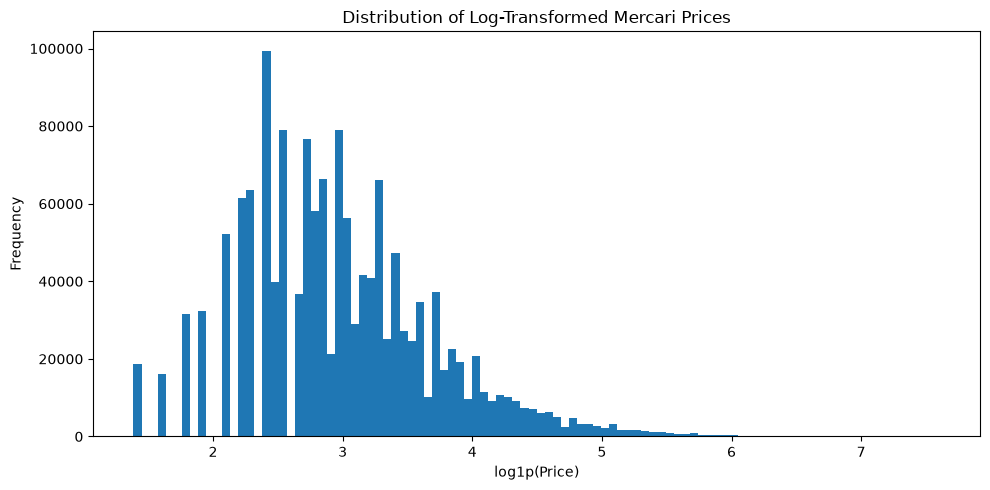

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

price_positive = train.loc[train["price"] > 0, "price"]
log_price = np.log1p(price_positive)

print(f"원본 price 왜도: {price_positive.skew():.4f}")
print(f"log1p(price) 왜도: {log_price.skew():.4f}")

plt.figure(figsize=(10, 5))

plt.hist(log_price, bins=100)

plt.xlabel("log1p(Price)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Mercari Prices")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/02_log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.1.4 로그 변환을 통한 가격 분포 개선

원본 `price`의 왜도는 **11.3937**로 매우 높은 양의 왜도를 보였다. 이는 대부분의 상품이 낮은 가격대에 집중되어 있는 반면, 일부 고가 상품이 존재하여 오른쪽 꼬리가 길게 형성되어 있음을 의미한다.

가격 분포의 비대칭성을 완화하기 위해 `log1p(price)` 변환을 적용하였다.

변환 결과 왜도는 다음과 같이 크게 감소하였다.

- 원본 `price`: **11.3937**
- `log1p(price)`: **0.6991**

즉, 로그 변환을 통해 왜도가 약 **10.69포인트 감소**하였으며, 가격 분포의 비대칭성이 크게 완화되었다.

히스토그램에서도 로그 변환 이후 극단적인 오른쪽 꼬리가 압축되고 보다 대칭적인 분포에 가까워지는 모습을 확인하였다.

따라서 이후 통계적 회귀분석 및 머신러닝 모델링에서는 원본 가격뿐만 아니라 `log1p(price)`를 Target으로 사용하는 방안도 함께 고려한다.

단, 로그 변환을 최종적인 Target으로 확정하지 않고 원본 Target과 로그 변환 Target을 활용한 모델의 예측 성능 및 잔차 특성을 비교하여 최종적으로 결정한다.

In [6]:
Q1 = train["price"].quantile(0.25)
Q3 = train["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"하한: {lower_bound}")
print(f"상한: {upper_bound}")

print(f"하한 미만: {(train['price'] < lower_bound).sum():,}건")
print(f"상한 초과: {(train['price'] > upper_bound).sum():,}건")

Q1: 10.0
Q3: 29.0
IQR: 19.0
하한: -18.5
상한: 57.5
하한 미만: 0건
상한 초과: 119,352건


In [7]:
outlier_mask = train["price"] > upper_bound

print(f"IQR 기준 이상치 수: {outlier_mask.sum():,}건")
print(f"IQR 기준 이상치 비율: {outlier_mask.mean() * 100:.2f}%")

IQR 기준 이상치 수: 119,352건
IQR 기준 이상치 비율: 8.05%


In [8]:
train.loc[train["price"] > upper_bound, "price"].describe()

count    119352.000000
mean        112.881146
std          93.847746
min          58.000000
25%          66.000000
50%          84.000000
75%         121.000000
max        2009.000000
Name: price, dtype: float64

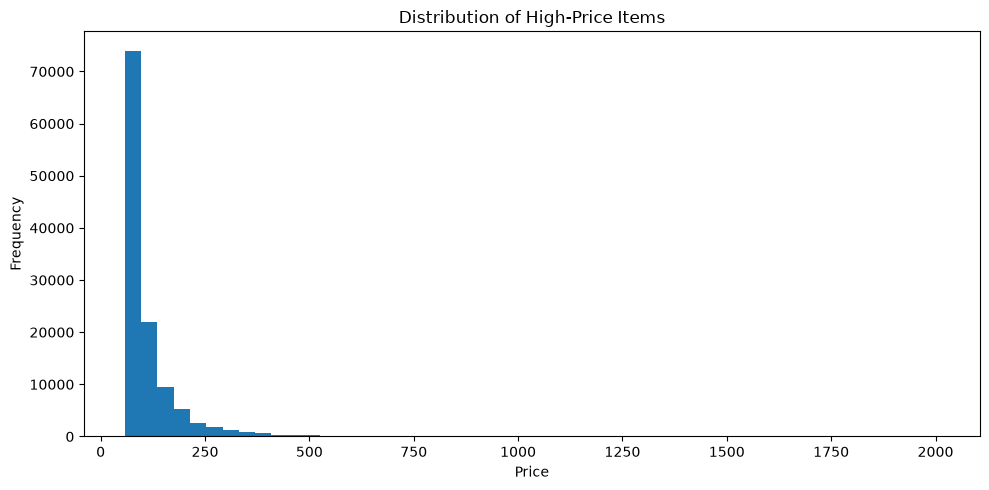

In [9]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.hist(
    train.loc[train["price"] > upper_bound, "price"],
    bins=50
)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of High-Price Items")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/03_high_price_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.2.1 IQR 기준 이상치 탐색

가격 변수의 극단값을 정량적으로 확인하기 위해 IQR(Interquartile Range) 기준을 적용하였다.

Q1은 10, Q3는 29로 확인되었으며 IQR은 19였다. 이에 따라 상한 기준은 57.5로 계산되었다.

IQR 기준으로 57.5를 초과하는 상품은 총 **119,352건(8.05%)**으로 나타났다.

전체 데이터의 약 8%가 통계적 이상치 후보로 분류되었으나, 이를 모두 데이터 오류로 판단하여 제거하는 것은 적절하지 않다고 판단하였다. Mercari와 같은 온라인 중고거래 데이터에서는 고가 상품 자체가 정상적인 상품일 가능성이 존재하기 때문이다.

따라서 본 분석에서는 IQR 기준을 '이상치 제거 기준'이 아니라 **가격 분포의 극단값을 탐색하기 위한 기준**으로 활용한다.

특히 가격 분포가 강한 우측 왜도를 보이고 있으며 `log1p(price)` 변환을 통해 왜도가 11.39에서 0.70으로 크게 완화되었으므로, 고가 상품을 일괄 제거하기보다는 로그 변환을 통해 극단값의 영향력을 완화하는 방법을 우선적으로 검토한다.

In [10]:
train.loc[train["price"] > upper_bound, "price"].describe()

count    119352.000000
mean        112.881146
std          93.847746
min          58.000000
25%          66.000000
50%          84.000000
75%         121.000000
max        2009.000000
Name: price, dtype: float64

### 3.2.2 IQR 이상치 후보의 가격 분포

IQR 기준 상한인 57.5를 초과하는 119,352건의 가격 분포를 추가적으로 확인하였다.

해당 관측치의 평균 가격은 112.88, 중앙값은 84.00으로 나타났으며, 1사분위수는 66.00, 3사분위수는 121.00이었다. 최대값은 2,009로 일부 극단적으로 높은 가격의 상품도 존재하였다.

특히 IQR 기준 이상치 후보가 전체 데이터의 8.05%에 달하고, 해당 집단의 중앙값이 84로 나타난 점을 고려하면 이들을 모두 데이터 오류로 판단하여 제거하는 것은 적절하지 않다고 판단하였다.

따라서 본 분석에서는 IQR 기준을 이상치의 존재를 탐색하는 기준으로 활용하되, 고가 상품을 일괄적으로 제거하지 않는다.

가격 분포 자체가 강한 우측 왜도를 보이고 있으며 `log1p(price)` 변환을 통해 왜도가 11.39에서 0.70으로 크게 감소한 점을 고려하여, 정상적인 고가 상품은 유지하고 로그 변환을 통해 극단값의 영향력을 완화하는 방향을 우선적으로 고려한다.

단, `price = 0`인 874건은 고가 상품과 달리 유효한 판매가격으로 보기 어려우므로 별도의 비정상값으로 구분하여 이후 전처리 단계에서 제외한다.

In [11]:
train.loc[
    train["price"].nlargest(20).index,
    ["name", "category_name", "brand_name", "price"]
].sort_values("price", ascending=False)

,name,category_name,brand_name,price
760469,NEW Chanel WOC Caviar Gold Hardware,Women/Women's Handbags/Shoulder Bag,Chanel,2009.0
1262245,NEW-Chanel Boy Wallet o Chain WOC Caviar,Women/Women's Handbags/Messenger & Crossbody,Chanel,2006.0
1393600,David Yurman Wheaton ring,Women/Jewelry/Rings,David Yurman,2004.0
415027,Chanel Classic Jumbo Single flap bag,Women/Women's Handbags/Shoulder Bag,Chanel,2000.0
742113,Chanel Chevron Fuschia Pink 2,Women/Women's Handbags/Shoulder Bag,Chanel,2000.0
778940,Mary kay,Beauty/Makeup/Face,Mary Kay,2000.0
956343,Chanel Black wallet on chain,Women/Women's Handbags/Messenger & Crossbody,Chanel,2000.0
1250053,Brand New Chanel CC Quilted WOC,Women/Women's Handbags/Messenger & Crossbody,Chanel,2000.0
1445348,Vs2/I 1ct Diamond Engagement Ring,Women/Jewelry/Rings,NaN,2000.0
952000,Chanel J12 H0682 Wrist Watch for Women,Women/Women's Accessories/Watches,NaN,1999.0


### 3.2.3 극단값의 실제 데이터 검토

IQR 기준으로 이상치 후보로 분류된 고가 상품이 실제 데이터 오류인지 확인하기 위해 가격 상위 상품의 상품명, 카테고리 및 브랜드를 검토하였다.

그 결과 상위 가격 상품에는 Chanel, Louis Vuitton, Celine 등의 명품 가방 및 액세서리와 Apple iPad Pro, 고가 주얼리 등 실제 고가 상품으로 판단할 수 있는 상품들이 포함되어 있었다.

따라서 단순히 IQR 기준을 적용하여 가격이 57.5를 초과하는 모든 관측치를 이상값으로 제거하는 것은 적절하지 않다고 판단하였다.

본 분석에서는 통계적 이상치와 데이터 오류를 구분하였다. IQR 기준을 초과하는 고가 상품은 실제 상품 가격의 자연스러운 변동으로 판단하여 유지하고, 가격 분포의 극단적인 우측 왜도는 앞서 확인한 `log1p(price)` 변환을 통해 완화한다.

반면 `price = 0`인 874건은 실제 판매가격으로 해석하기 어려우므로 별도의 비정상값으로 판단하여 이후 전처리 단계에서 제거한다.

In [12]:
# 상품상태 별
condition_counts = (
    train["item_condition_id"]
    .value_counts()
    .sort_index()
)

condition_counts

item_condition_id
1    640549
2    375479
3    432161
4     31962
5      2384
Name: count, dtype: int64

In [13]:
condition_ratio = (
    train["item_condition_id"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

condition_ratio

item_condition_id
1    43.21
2    25.33
3    29.15
4     2.16
5     0.16
Name: proportion, dtype: float64

### 3.3.1 상품 상태별 분포

`item_condition_id`의 빈도를 확인한 결과, 상품 상태 1이 640,549건(43.20%)으로 가장 높은 비중을 차지했으며, 상태 2가 375,479건(25.32%), 상태 3이 432,161건(29.15%)으로 나타났다.

반면 상태 4와 5는 각각 31,962건(2.16%), 2,384건(0.16%)으로 상대적으로 매우 적었다.

전체적으로 상품 상태 1~3에 약 97.7%의 관측치가 집중되어 있어 상품 상태 변수의 분포가 일부 범주에 편중되어 있음을 확인하였다.

다만 범주별 관측치 수와 가격 수준은 별개의 문제이므로, 상품 상태가 실제 상품 가격에 영향을 미치는지는 이후 `3.4 변수와 가격 관계`에서 상태별 가격 분포를 비교하여 확인한다.

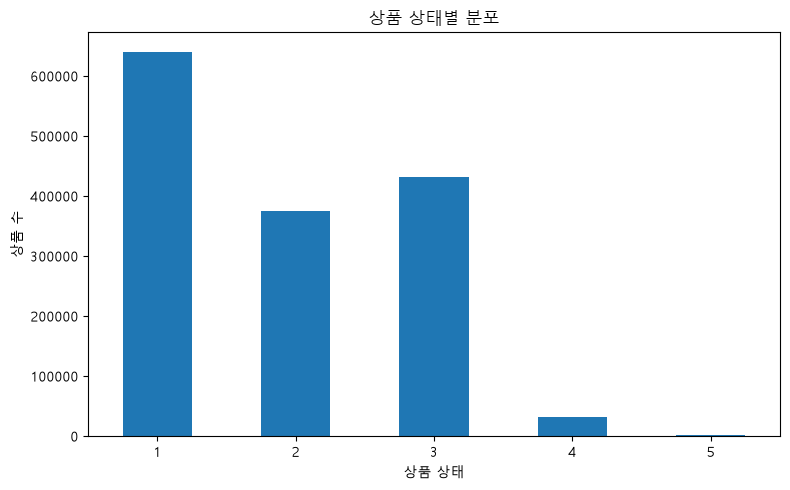

In [14]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 저장 폴더
os.makedirs("../outputs/figures", exist_ok=True)

condition_counts = (
    train["item_condition_id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

condition_counts.plot(kind="bar")

plt.xlabel("상품 상태")
plt.ylabel("상품 수")
plt.title("상품 상태별 분포")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/04_item_condition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# 배송비 부담여부
shipping_counts = (
    train["shipping"]
    .value_counts()
    .sort_index()
)

shipping_counts

shipping
0    819435
1    663100
Name: count, dtype: int64

In [16]:
# 비율
shipping_ratio = (
    train["shipping"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

shipping_ratio

shipping
0    55.27
1    44.73
Name: proportion, dtype: float64

### 3.3.2 배송비 부담 주체별 분포

`shipping` 변수는 배송비 부담 주체를 나타내는 범주형 변수로, 0은 판매자 부담, 1은 구매자 부담을 의미한다.

분석 결과 판매자 부담 상품은 819,435건(55.27%), 구매자 부담 상품은 663,100건(44.73%)으로 나타났다.

판매자 부담 상품이 약 10.5%p 높은 비중을 차지하지만 두 범주가 비교적 균형 있게 분포하고 있어 특정 범주에 극단적으로 편중된 구조는 아닌 것으로 판단된다.

따라서 `shipping` 변수는 두 범주 간 충분한 관측치를 확보하고 있어 상품 가격과의 관계를 분석하기에 적절한 범주형 변수로 판단하였다.

단, 현재 분석은 변수의 분포를 확인하는 단계이므로 배송비 부담 여부가 가격에 실제 영향을 미치는지는 이후 변수-가격 관계 분석에서 검증한다.

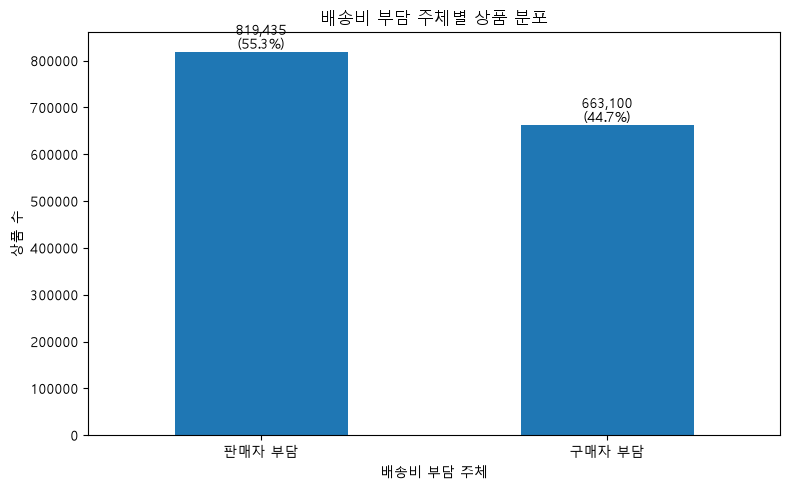

In [17]:
shipping_counts = train["shipping"].value_counts().sort_index()

shipping_labels = {
    0: "판매자 부담",
    1: "구매자 부담"
}

shipping_counts.index = shipping_counts.index.map(shipping_labels)

shipping_ratio = shipping_counts / shipping_counts.sum() * 100

plt.figure(figsize=(8, 5))

ax = shipping_counts.plot(kind="bar")

plt.xlabel("배송비 부담 주체")
plt.ylabel("상품 수")
plt.title("배송비 부담 주체별 상품 분포")

plt.xticks(rotation=0)

for i, (count, ratio) in enumerate(
    zip(shipping_counts, shipping_ratio)
):
    ax.text(
        i,
        count,
        f"{count:,}\n({ratio:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/05_shipping_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# 카테고리 분석
category_counts = (
    train["category_name"]
    .value_counts()
)

category_counts.head(20)

category_name
Women/Athletic Apparel/Pants, Tights, Leggings                 60177
Women/Tops & Blouses/T-Shirts                                  46380
Beauty/Makeup/Face                                             34335
Beauty/Makeup/Lips                                             29910
Electronics/Video Games & Consoles/Games                       26557
Beauty/Makeup/Eyes                                             25215
Electronics/Cell Phones & Accessories/Cases, Covers & Skins    24676
Women/Underwear/Bras                                           21274
Women/Tops & Blouses/Tank, Cami                                20284
Women/Tops & Blouses/Blouse                                    20284
Women/Dresses/Above Knee, Mini                                 20082
Women/Jewelry/Necklaces                                        19758
Women/Athletic Apparel/Shorts                                  19528
Beauty/Makeup/Makeup Palettes                                  19103
Women/Shoes/Boots   

### 3.3.3 카테고리별 상품 분포

`category_name`의 상품 수를 기준으로 상위 20개 카테고리를 확인하였다.

가장 많은 카테고리는 `Women/Athletic Apparel/Pants, Tights, Leggings`로 60,177건이었으며, `Women/Tops & Blouses/T-Shirts`가 46,380건, `Beauty/Makeup/Face`가 34,335건으로 뒤를 이었다.

상위 카테고리에는 Women 의류 및 액세서리와 Beauty 관련 상품이 다수 포함되어 있어 특정 상품군에 관측치가 집중되어 있는 것으로 나타났다.

한편 `category_name`은 총 1,287개의 범주를 가지고 있어 범주 수가 많은 고카디널리티(high cardinality) 변수에 해당한다. 따라서 모든 범주를 동일하게 시각화하기보다는 상위 범주의 분포를 우선적으로 확인하였다.

다만 상품 수가 많은 카테고리가 반드시 높은 가격을 가지는 것은 아니므로, 카테고리가 상품 가격에 미치는 영향은 이후 변수와 가격의 관계 분석에서 별도로 확인한다.

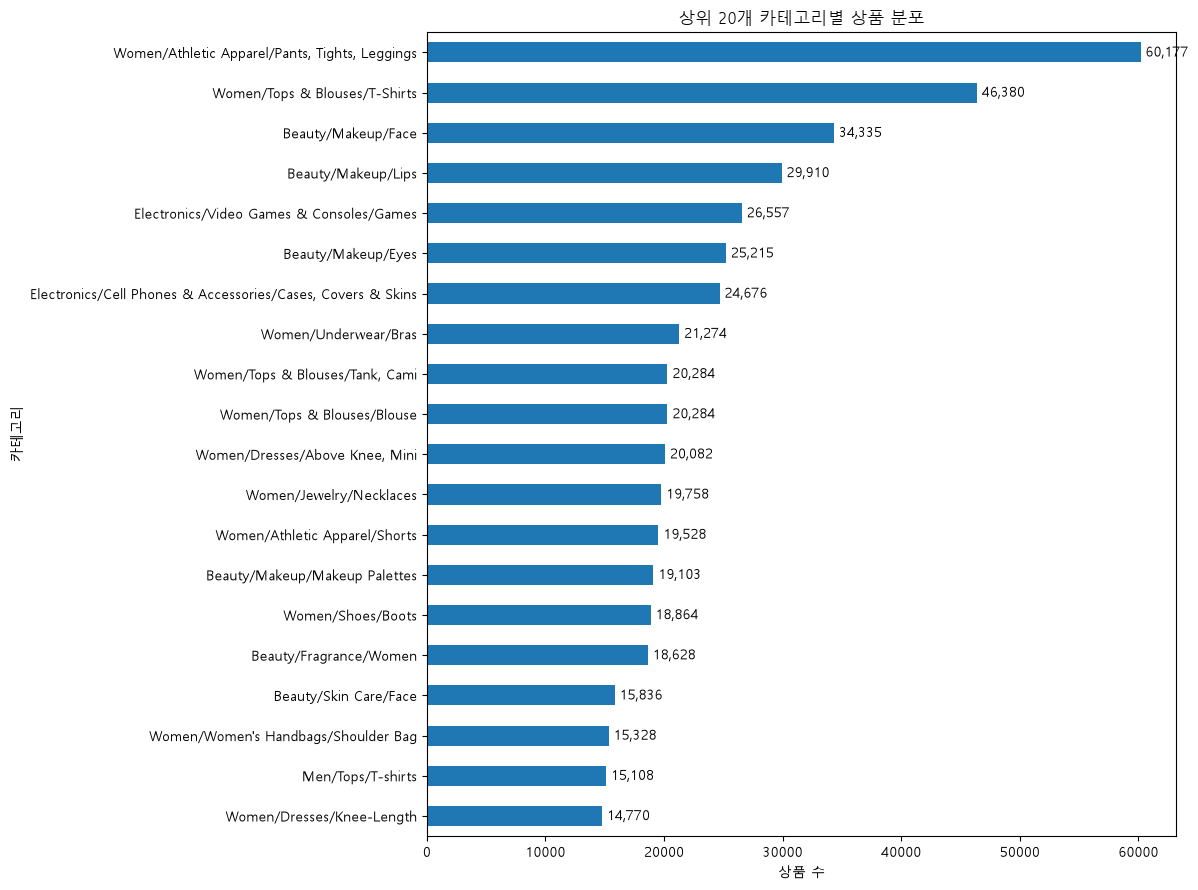

In [19]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

top_categories = (
    train["category_name"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 9))

ax = top_categories.plot(kind="barh")

plt.xlabel("상품 수")
plt.ylabel("카테고리")
plt.title("상위 20개 카테고리별 상품 분포")

for i, count in enumerate(top_categories):
    ax.text(
        count,
        i,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_top20_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# 브랜드 분석
brand_counts = (
    train["brand_name"]
    .value_counts()
)

brand_counts.head(20)

brand_name
PINK                 54088
Nike                 54043
Victoria's Secret    48036
LuLaRoe              31024
Apple                17322
FOREVER 21           15186
Nintendo             15007
Lululemon            14558
Michael Kors         13928
American Eagle       13254
Rae Dunn             12305
Sephora              12172
Coach                10463
Disney               10360
Bath & Body Works    10354
Adidas               10202
Funko                 9237
Under Armour          8461
Sony                  7994
Old Navy              7567
Name: count, dtype: int64

### 3.3.4 브랜드별 상품 분포

`brand_name`의 빈도를 기준으로 상위 20개 브랜드를 확인하였다.

가장 많은 브랜드는 `PINK` 54,088건, `Nike` 54,043건, `Victoria's Secret` 48,036건으로 나타났으며, 이후 `LuLaRoe`, `Apple`, `FOREVER 21`, `Nintendo` 등이 뒤를 이었다.

상위 브랜드에는 패션·뷰티 브랜드뿐만 아니라 Apple, Nintendo, Sony 등 전자제품 관련 브랜드도 포함되어 있어 다양한 상품군이 혼재되어 있음을 확인할 수 있다.

한편 `brand_name`은 총 4,809개의 고유 브랜드를 가지는 고카디널리티 변수이며, 전체 데이터의 42.68%가 결측으로 나타났다.

따라서 브랜드 변수는 상품 가격을 설명하는 데 유용한 정보가 될 가능성이 있지만, 높은 카디널리티와 높은 결측률을 동시에 가지고 있어 이후 전처리 및 인코딩 과정에서 별도의 전략이 필요하다.

특히 결측 브랜드를 단순히 제거할 경우 전체 데이터의 상당 부분을 손실할 수 있으므로, 이후 모델링 단계에서는 결측 자체를 하나의 범주로 처리하거나 빈도 기반 인코딩 및 적절한 범주 축소 방법 등을 검토한다.

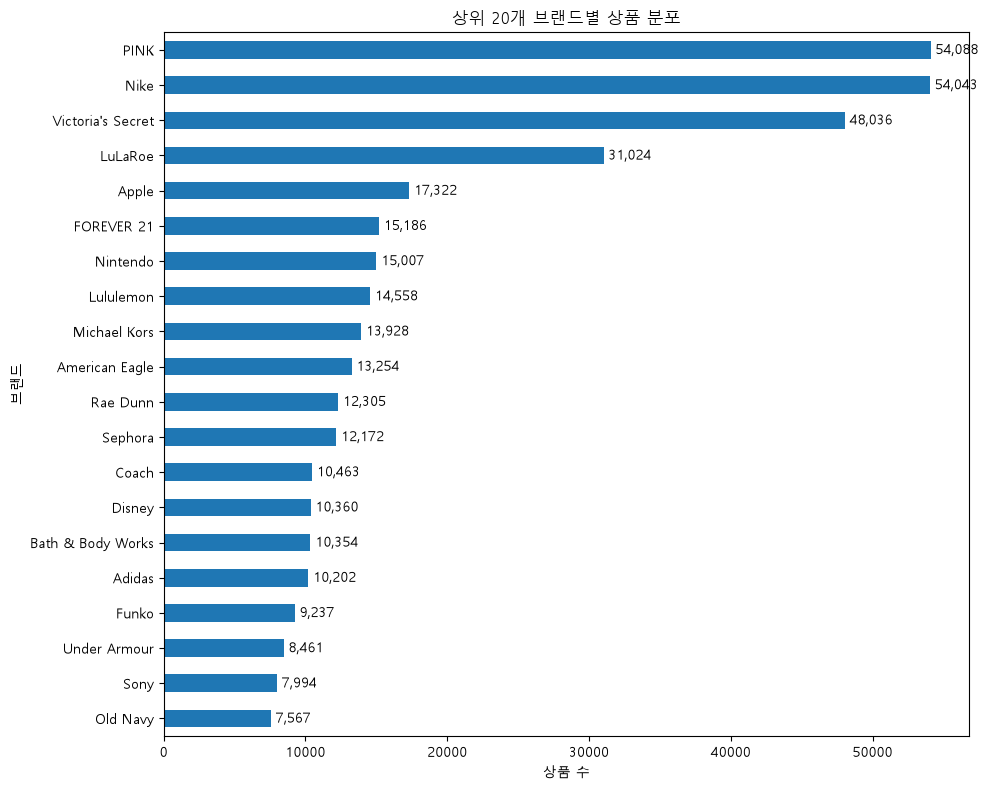

In [21]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

top_brands = (
    train["brand_name"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 8))

ax = top_brands.plot(kind="barh")

plt.xlabel("상품 수")
plt.ylabel("브랜드")
plt.title("상위 20개 브랜드별 상품 분포")

for i, count in enumerate(top_brands):
    ax.text(
        count,
        i,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/07_top20_brand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
condition_price = (
    train.groupby("item_condition_id")["price"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

condition_price

,count,mean,median,std
item_condition_id,,,,
1,640549,26.49,18.0,35.42
2,375479,27.56,17.0,42.13
3,432161,26.54,16.0,40.03
4,31962,24.35,15.0,35.68
5,2384,31.70,19.0,39.53


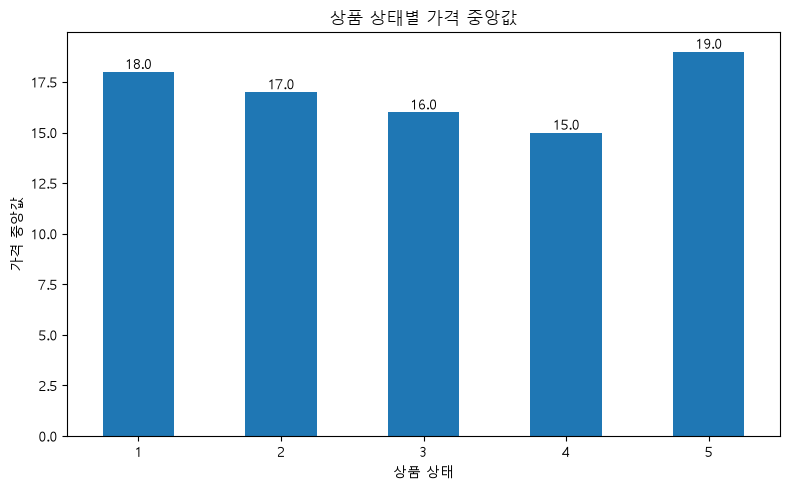

In [23]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

condition_median = (
    train.groupby("item_condition_id")["price"]
    .median()
    .sort_index()
)

plt.figure(figsize=(8, 5))

ax = condition_median.plot(kind="bar")

plt.xlabel("상품 상태")
plt.ylabel("가격 중앙값")
plt.title("상품 상태별 가격 중앙값")

plt.xticks(rotation=0)

for i, value in enumerate(condition_median):
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/08_condition_price_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.4.1 상품 상태와 가격의 관계

상품 상태별 가격을 비교한 결과, 평균 가격은 24.35~31.70, 중앙값은 15~19 범위로 나타났다.

관측치가 많은 상품 상태 1~3의 중앙값은 각각 18, 17, 16으로 큰 차이를 보이지 않았으며, 평균 가격 역시 26.49, 27.56, 26.54로 유사한 수준이었다.

상태 5의 평균 가격은 31.70으로 가장 높게 나타났지만, 해당 범주의 관측치가 2,384건으로 전체 데이터에서 차지하는 비중이 매우 낮기 때문에 이를 일반적인 가격 특성으로 해석하는 데에는 주의가 필요하다.

또한 대부분의 범주에서 평균 가격과 중앙값 사이에 차이가 나타나 가격 분포의 우측 왜도 및 고가 상품의 영향을 확인할 수 있다.

따라서 탐색적 분석 단계에서는 상품 상태에 따른 가격 차이가 존재하지만 그 차이가 크지는 않은 것으로 관찰되며, 상품 상태가 가격 예측에 미치는 영향은 다른 변수들과 함께 모델링 단계에서 종합적으로 평가할 필요가 있다.

In [24]:
# 그룹별 가격 통계
shipping_price = (
    train.groupby("shipping")["price"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

shipping_price

,count,mean,median,std
shipping,,,,
0,819435,30.11,20.0,39.54
1,663100,22.57,14.0,36.96


In [25]:
# 한글 적용
shipping_price.index = shipping_price.index.map({
    0: "판매자 부담",
    1: "구매자 부담"
})

shipping_price

,count,mean,median,std
shipping,,,,
판매자 부담,819435,30.11,20.0,39.54
구매자 부담,663100,22.57,14.0,36.96


### 3.4.2 배송비 부담과 가격의 관계

배송비 부담 주체에 따른 가격 차이를 확인한 결과, 판매자가 배송비를 부담하는 상품의 가격이 구매자가 배송비를 부담하는 상품보다 높게 나타났다.

판매자 부담 상품의 평균 가격은 30.11, 중앙값은 20.00이었으며, 구매자 부담 상품은 평균 22.57, 중앙값 14.00으로 나타났다.

특히 가격 분포의 영향을 상대적으로 적게 받는 중앙값을 기준으로 비교하면, 판매자 부담 상품의 가격이 구매자 부담 상품보다 약 42.9% 높았다.

이는 배송비 부담 여부가 상품 가격과 관련되어 있을 가능성을 보여주며, `shipping` 변수가 가격 예측 모델에서 유의미한 설명변수가 될 가능성을 시사한다.

그러나 본 분석은 관찰된 변수 간의 관계를 확인한 것이므로 배송비 부담이 가격을 직접적으로 증가시킨다고 해석할 수는 없다. 상품 카테고리, 브랜드, 상품 상태 등의 다른 변수에 의해 이러한 차이가 발생했을 가능성도 존재한다.

따라서 이후 회귀모형 및 머신러닝 모델에서 다른 변수들을 통제한 상태에서 `shipping` 변수의 영향력을 추가적으로 확인한다.

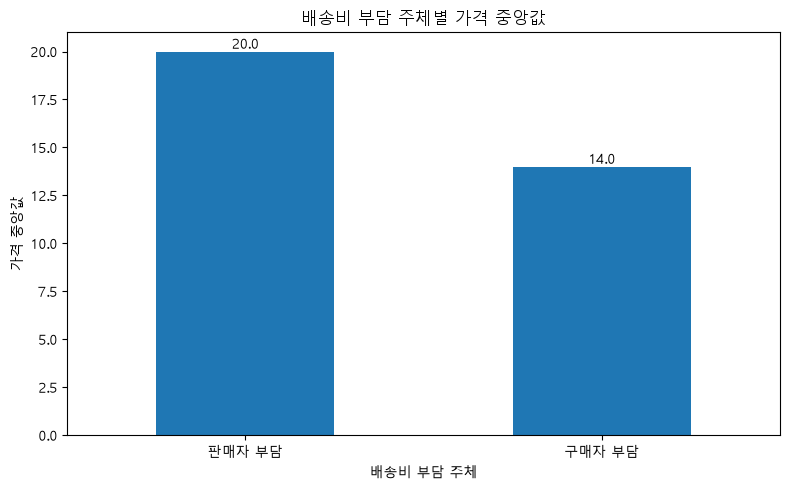

In [26]:
# 시각화
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

shipping_median = (
    train.groupby("shipping")["price"]
    .median()
)

shipping_median.index = shipping_median.index.map({
    0: "판매자 부담",
    1: "구매자 부담"
})

plt.figure(figsize=(8, 5))

ax = shipping_median.plot(kind="bar")

plt.xlabel("배송비 부담 주체")
plt.ylabel("가격 중앙값")
plt.title("배송비 부담 주체별 가격 중앙값")

plt.xticks(rotation=0)

for i, value in enumerate(shipping_median):
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/09_shipping_price_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x500 with 0 Axes>

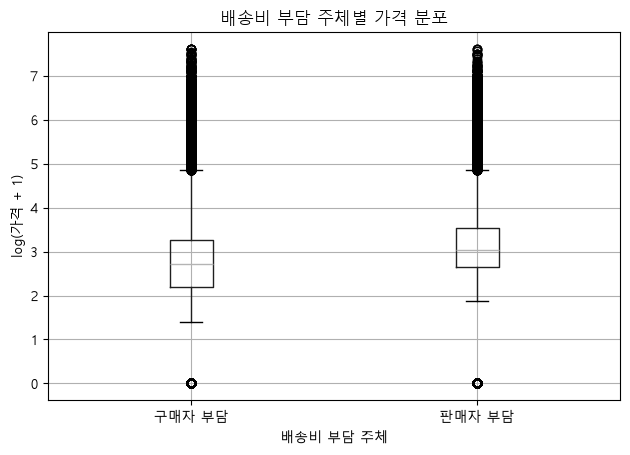

In [27]:
import numpy as np

plot_data = train.copy()

plot_data["log_price"] = np.log1p(plot_data["price"])

plot_data["배송비 부담"] = plot_data["shipping"].map({
    0: "판매자 부담",
    1: "구매자 부담"
})

plt.figure(figsize=(8, 5))

plot_data.boxplot(
    column="log_price",
    by="배송비 부담"
)

plt.xlabel("배송비 부담 주체")
plt.ylabel("log(가격 + 1)")
plt.title("배송비 부담 주체별 가격 분포")

plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/10_shipping_logprice_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# 카테고리 * 가격
top_categories = (
    train["category_name"]
    .value_counts()
    .head(20)
    .index
)

category_price = (
    train[train["category_name"].isin(top_categories)]
    .groupby("category_name")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
    .round(2)
)

category_price

,count,mean,median,std
category_name,,,,
Women/Women's Handbags/Shoulder Bag,15328,65.98,36.0,113.56
Women/Shoes/Boots,18864,42.65,31.0,37.86
"Women/Athletic Apparel/Pants, Tights, Leggings",60177,34.39,29.0,24.40
Women/Dresses/Knee-Length,14770,30.09,25.0,23.48
Beauty/Makeup/Makeup Palettes,19103,25.56,22.0,27.50
Beauty/Fragrance/Women,18628,23.72,18.0,21.44
Electronics/Video Games & Consoles/Games,26557,24.12,16.0,29.14
"Women/Dresses/Above Knee, Mini",20082,21.87,16.0,21.07
Women/Underwear/Bras,21274,18.64,15.0,13.36


### 3.4.3 카테고리와 가격의 관계

상품 수가 많은 상위 20개 카테고리를 대상으로 가격 수준을 비교한 결과, 카테고리에 따라 상품 가격의 중앙값에 상당한 차이가 나타났다.

가격 중앙값이 가장 높은 카테고리는 `Women/Women's Handbags/Shoulder Bag`으로 36.00이었으며, `Women/Shoes/Boots`가 31.00, `Women/Athletic Apparel/Pants, Tights, Leggings`가 29.00으로 뒤를 이었다.

반면 `Electronics/Cell Phones & Accessories/Cases, Covers & Skins`의 중앙값은 10.00, `Women/Tops & Blouses/Tank, Cami`와 `Women/Tops & Blouses/Blouse`는 각각 12.00으로 상대적으로 낮은 가격 수준을 보였다.

상위 카테고리 간 가격 중앙값이 10~36의 범위로 나타나 카테고리에 따라 상품의 일반적인 가격 수준이 상당히 다르다는 것을 확인하였다.

특히 `Shoulder Bag`은 평균 가격이 65.98, 중앙값이 36.00, 표준편차가 113.56으로 나타나 평균과 중앙값의 차이가 크고 가격 변동성 또한 높은 것으로 나타났다. 이는 해당 카테고리에 상대적으로 고가의 상품이 포함되어 있을 가능성을 보여준다.

따라서 `category_name`은 상품 가격의 체계적인 차이를 설명할 수 있는 중요한 변수로 판단되며, 가격 예측 모델에서 주요 설명변수로 활용할 가치가 있다.

다만 `category_name`은 1,287개의 범주를 가지는 고카디널리티 변수이므로, 머신러닝 모델링 단계에서는 적절한 범주형 변수 인코딩 및 희소 범주 처리 전략이 필요하다.

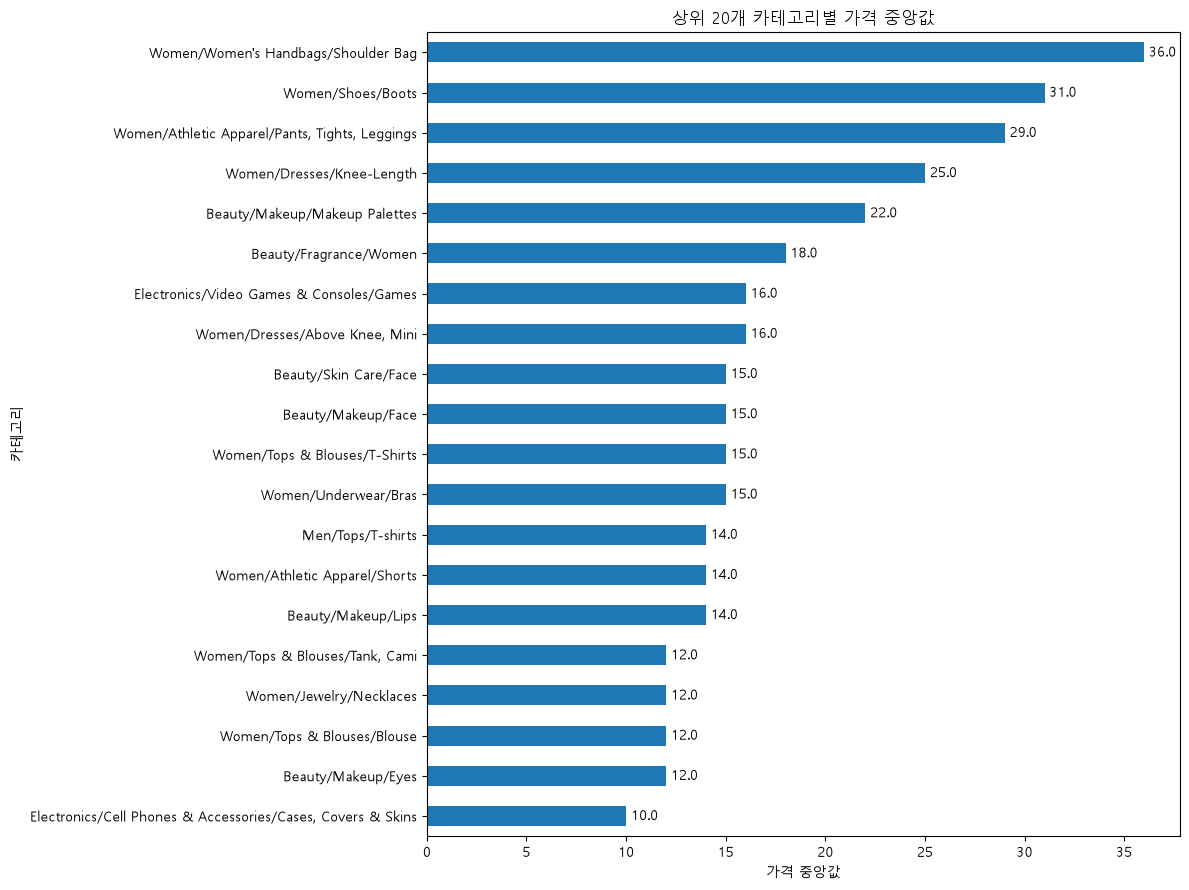

In [29]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

category_median = category_price["median"].sort_values()

plt.figure(figsize=(12, 9))

ax = category_median.plot(kind="barh")

plt.xlabel("가격 중앙값")
plt.ylabel("카테고리")
plt.title("상위 20개 카테고리별 가격 중앙값")

for i, value in enumerate(category_median):
    ax.text(
        value,
        i,
        f" {value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/11_category_price_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\mega\AppData\Local\Temp\ipykernel_6460\568058255.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1400x900 with 0 Axes>

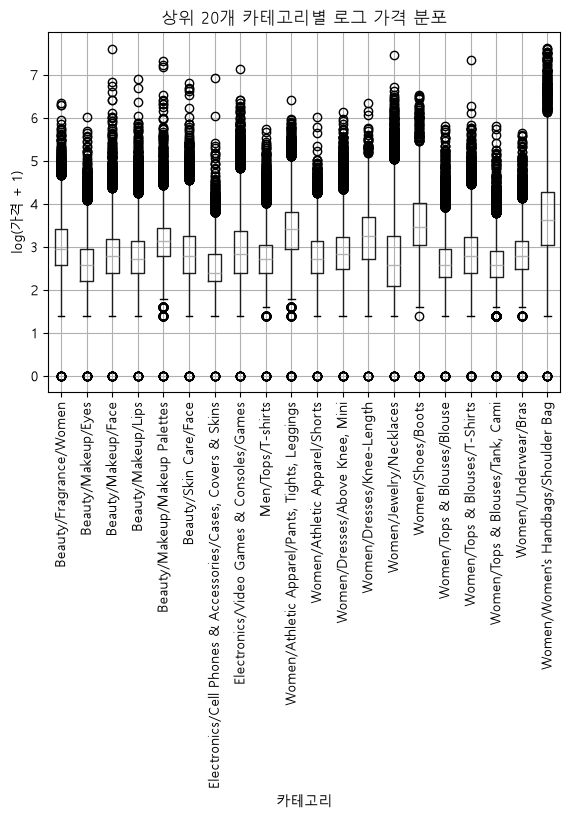

In [30]:
# 극단값 방지
import numpy as np

category_plot = train[
    train["category_name"].isin(top_categories)
].copy()

category_plot["log_price"] = np.log1p(category_plot["price"])

category_order = (
    category_plot
    .groupby("category_name")["log_price"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 9))

category_plot.boxplot(
    column="log_price",
    by="category_name",
    rot=90
)

plt.xlabel("카테고리")
plt.ylabel("log(가격 + 1)")
plt.title("상위 20개 카테고리별 로그 가격 분포")

plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/12_category_logprice_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# 브랜드 * 가격
top_brands = (
    train["brand_name"]
    .value_counts()
    .head(20)
    .index
)

brand_price = (
    train[train["brand_name"].isin(top_brands)]
    .groupby("brand_name")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
    .round(2)
)

brand_price

,count,mean,median,std
brand_name,,,,
Michael Kors,13928,62.25,49.0,51.68
Lululemon,14558,47.10,39.0,31.39
Coach,10463,41.14,31.0,36.53
Rae Dunn,12305,37.17,30.0,29.60
LuLaRoe,31024,33.67,29.0,19.72
Adidas,10202,43.13,25.0,54.83
Apple,17322,73.27,22.0,119.86
Nike,54043,30.76,22.0,26.34
PINK,54088,26.34,20.0,23.63


### 3.4.4 브랜드와 가격의 관계

상품 수가 많은 상위 20개 브랜드를 대상으로 가격 수준을 비교한 결과, 브랜드에 따라 상품 가격의 차이가 상당하게 나타났다.

가격 중앙값이 가장 높은 브랜드는 `Michael Kors`로 49.00이었으며, `Lululemon` 39.00, `Coach` 31.00, `Rae Dunn` 30.00, `LuLaRoe` 29.00 순으로 나타났다.

반면 `Old Navy`의 가격 중앙값은 11.00, `FOREVER 21`은 12.00, `Disney`는 13.00으로 상대적으로 낮은 가격 수준을 보였다.

상위 브랜드 간 가격 중앙값이 11~49의 범위로 나타나 브랜드에 따라 상품의 일반적인 가격 수준에 상당한 차이가 존재하는 것을 확인하였다.

특히 `Apple`은 평균 가격이 73.27인 반면 중앙값은 22.00으로 큰 차이를 보였으며, 표준편차 역시 119.86으로 높게 나타났다. 이는 일부 고가 상품이 평균 가격을 크게 상승시키고 있음을 의미하며, 가격 분포의 강한 우측 왜도를 다시 확인할 수 있는 결과이다.

따라서 `brand_name`은 상품 가격의 차이를 설명하는 데 중요한 변수일 가능성이 높으며, 가격 예측 모델에서 주요 설명변수로 활용할 가치가 있다.

다만 `brand_name`은 4,809개의 고유 브랜드와 42.68%의 높은 결측률을 가지고 있으므로, 모델링 단계에서는 고카디널리티와 결측값을 동시에 고려한 전처리 전략이 필요하다.

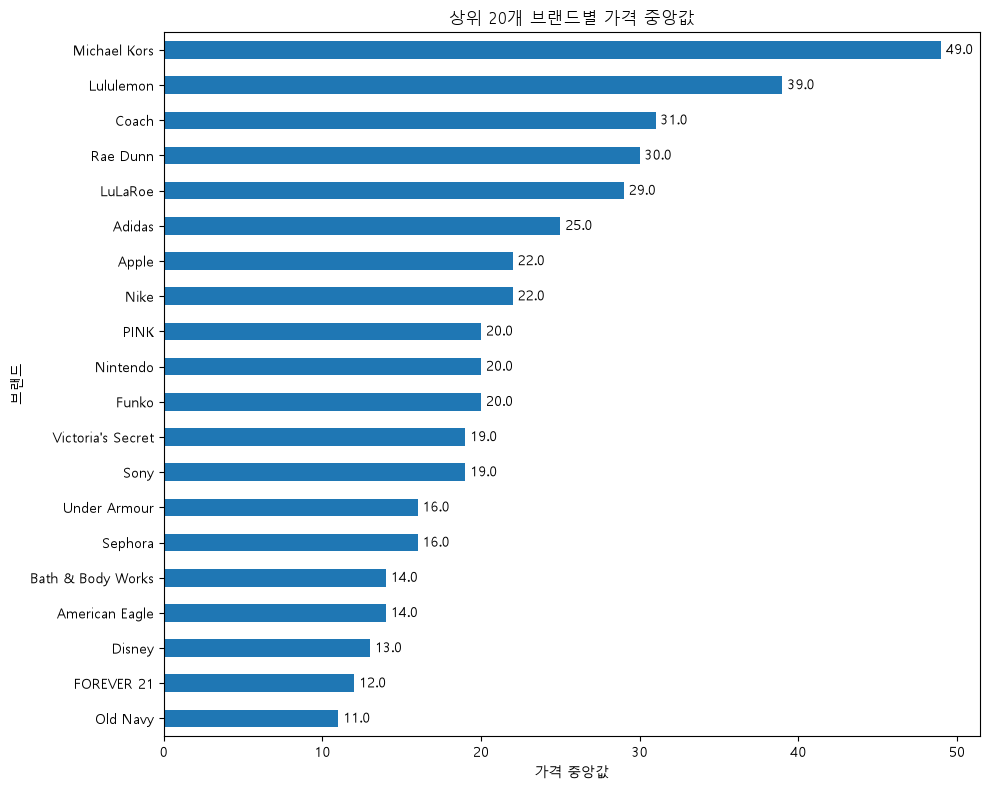

In [32]:
# 가격 중앙값 시각화
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("../outputs/figures", exist_ok=True)

brand_median = brand_price["median"].sort_values()

plt.figure(figsize=(10, 8))

ax = brand_median.plot(kind="barh")

plt.xlabel("가격 중앙값")
plt.ylabel("브랜드")
plt.title("상위 20개 브랜드별 가격 중앙값")

for i, value in enumerate(brand_median):
    ax.text(
        value,
        i,
        f" {value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/13_brand_price_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x900 with 0 Axes>

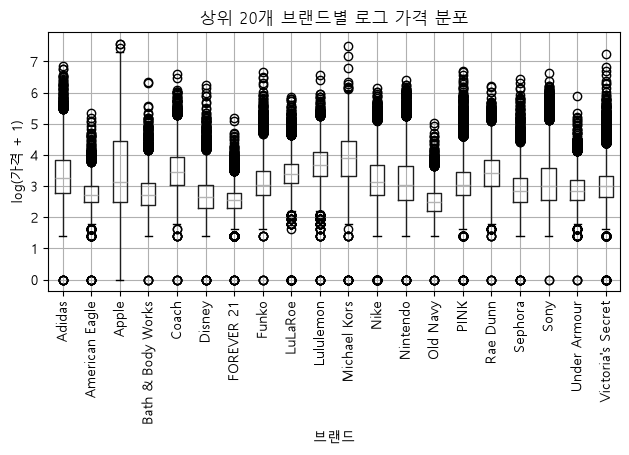

In [33]:
# 로그 가격 분포 비교
import numpy as np

brand_plot = train[
    train["brand_name"].isin(top_brands)
].copy()

brand_plot["log_price"] = np.log1p(brand_plot["price"])

plt.figure(figsize=(12, 9))

brand_plot.boxplot(
    column="log_price",
    by="brand_name",
    rot=90
)

plt.xlabel("브랜드")
plt.ylabel("log(가격 + 1)")
plt.title("상위 20개 브랜드별 로그 가격 분포")

plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/14_brand_logprice_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# 3장 EDA 최종 분석 데이터 저장
train.to_pickle("../data/processed/mercari_eda_final.pkl")

print("저장 완료:", train.shape)

저장 완료: (1482535, 8)
